In [2]:
import sklearn
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#no wrapping
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping

coffea_caff = pd.read_csv(r"../..\data\cleaned_data_w_class.csv")
coffee_data = coffea_caff.copy()



# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

# coffee_data = coffea_caff_clim.copy()

# #distinct_vals = coffee_data['caffeine_class'].value_counts()
# #print(distinct_vals)

# coffee_data.drop(columns=['specimen_id','longitude','latitude', 'source_crs', 'mada_geom_point', 'sampled_layers', 'nodata_layers', 'is_categorical_encoded'],inplace=True)

coffee_data.head

<bound method NDFrame.head of      clim_1_tmin1_jan  clim_2_tmin2_feb  clim_3_tmin3_mar  clim_4_tmin4_apr  clim_5_tmin5_may  clim_6_tmin6_jun  clim_7_tmin7_jul  clim_8_tmin8_aug  clim_9_tmin9_sep  clim_10_tmin10_oct  ...  env_78_wat_14  env_78_wat_13  env_78_wat_22  env_78_wat_17  env_78_wat_1.1  env_78_wat_18  env_78_wat_15  env_78_wat_0  caffeine_percent  caffeine_class
0               199.0             198.0             186.0             160.0             133.0             118.0             109.0             115.0             133.0               180.0  ...              0              0              0              0               0              0              0             0              0.00               0
1               217.5             218.0             216.0             211.0             194.0             177.0             171.0             170.0             173.0               199.0  ...              0              0              0              0               0              

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter rows where caffeine_percent equals 0.70
subset = coffee_data[coffee_data['caffeine_percent'] == 0.70]

# Compute statistics for temperature
temp_min = subset['temperature'].min()
temp_max = subset['temperature'].max()
temp_avg = subset['temperature'].mean()

# Compute statistics for precipitation
precip_min = subset['precipitation'].min()
precip_max = subset['precipitation'].max()
precip_avg = subset['precipitation'].mean()

# Prepare data for plotting
labels = ['Min', 'Max', 'Avg']
temperature_stats = [temp_min, temp_max, temp_avg]
precipitation_stats = [precip_min, precip_max, precip_avg]

# Set the positions and width for the bars
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
# Create grouped bar plot: shift the x positions for each bar group
ax.bar([p - width/2 for p in x], temperature_stats, width, label='Temperature')
ax.bar([p + width/2 for p in x], precipitation_stats, width, label='Precipitation')

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Value')
ax.set_title('Temperature and Precipitation Statistics for Caffeine Percent = 0.70')
ax.legend()

plt.show()


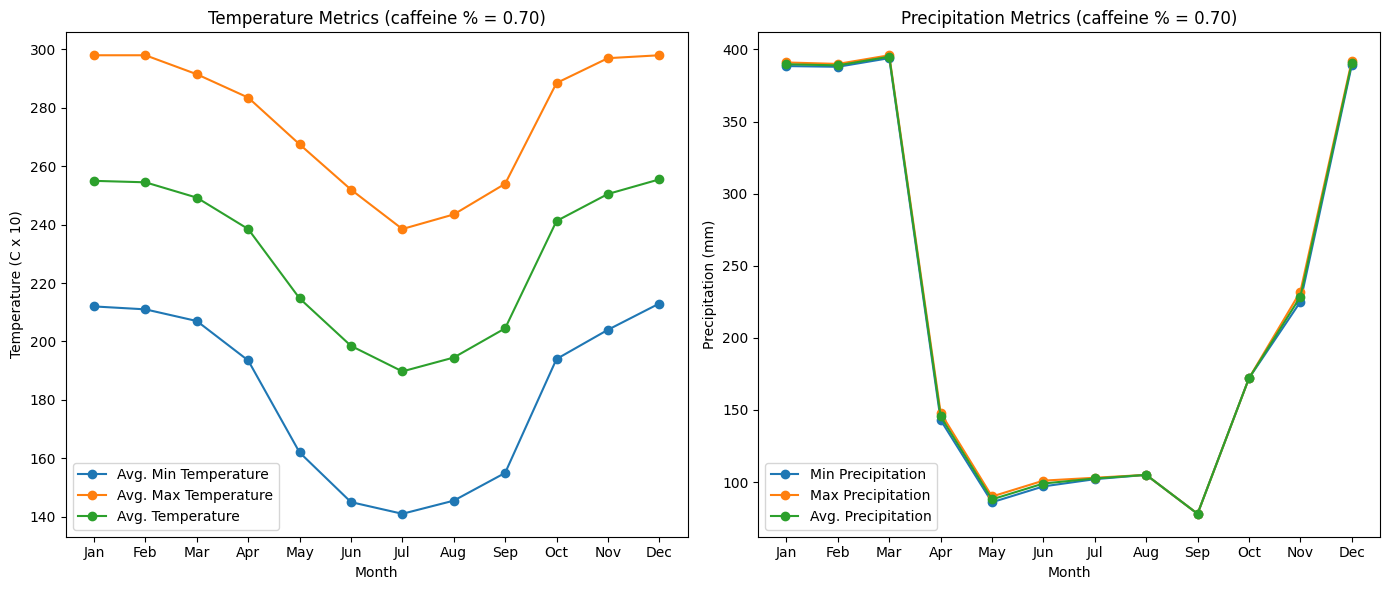

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter rows where caffeine_percent is 0.70
df_filtered = coffee_data[coffee_data['caffeine_percent'] == 0.70]

# Define column lists for each metric (ensure each list has exactly 12 columns)
temp_min_cols = [
    "clim_1_tmin1_jan", "clim_2_tmin2_feb", "clim_3_tmin3_mar",
    "clim_4_tmin4_apr", "clim_5_tmin5_may", "clim_6_tmin6_jun",
    "clim_7_tmin7_jul", "clim_8_tmin8_aug", "clim_9_tmin9_sep",
    "clim_10_tmin10_oct", "clim_11_tmin11_nov", "clim_12_tmin12_dec"
]

temp_max_cols = [
    "clim_13_tmax1_jan", "clim_14_tmax2_feb", "clim_15_tmax3_mar",
    "clim_16_tmax4_apr", "clim_17_tmax5_may", "clim_18_tmax6_jun",
    "clim_19_tmax7_jul", "clim_20_tmax8_aug", "clim_21_tmax9_sep",
    "clim_22_tmax10_oct", "clim_23_tmax11_nov", "clim_24_tmax12_dec"
]

precip_cols = [
    "clim_25_prec1_jan", "clim_26_prec2_feb", "clim_27_prec3_mar",
    "clim_28_prec4_apr", "clim_29_prec5_may", "clim_30_prec6_jun",
    "clim_31_prec7_jul", "clim_32_prec8_aug", "clim_33_prec9_sep",
    "clim_34_prec10_oct", "clim_35_prec11_nov", "clim_36_prec12_dec"
]

# Month labels for the x-axis
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute temperature metrics per month
tmin_avg = [df_filtered[col].mean() for col in temp_min_cols]
tmax_avg = [df_filtered[col].mean() for col in temp_max_cols]
temp_avg = [(min_val + max_val) / 2 for min_val, max_val in zip(tmin_avg, tmax_avg)]

# Compute precipitation metrics per month
precip_avg = [df_filtered[col].mean() for col in precip_cols]
precip_min = [df_filtered[col].min() for col in precip_cols]
precip_max = [df_filtered[col].max() for col in precip_cols]

# Plotting the metrics per month
plt.figure(figsize=(14, 6))

# Temperature subplot
plt.subplot(1, 2, 1)
plt.plot(months, tmin_avg, marker='o', label='Avg. Min Temperature')
plt.plot(months, tmax_avg, marker='o', label='Avg. Max Temperature')
plt.plot(months, temp_avg, marker='o', label='Avg. Temperature')
plt.title('Temperature Metrics (caffeine % = 0.70)')
plt.xlabel('Month')
plt.ylabel('Temperature (C x 10)')
plt.legend()

# Precipitation subplot
plt.subplot(1, 2, 2)
plt.plot(months, precip_min, marker='o', label='Min Precipitation')
plt.plot(months, precip_max, marker='o', label='Max Precipitation')
plt.plot(months, precip_avg, marker='o', label='Avg. Precipitation')
plt.title('Precipitation Metrics (caffeine % = 0.70)')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.legend()

plt.tight_layout()
plt.show()



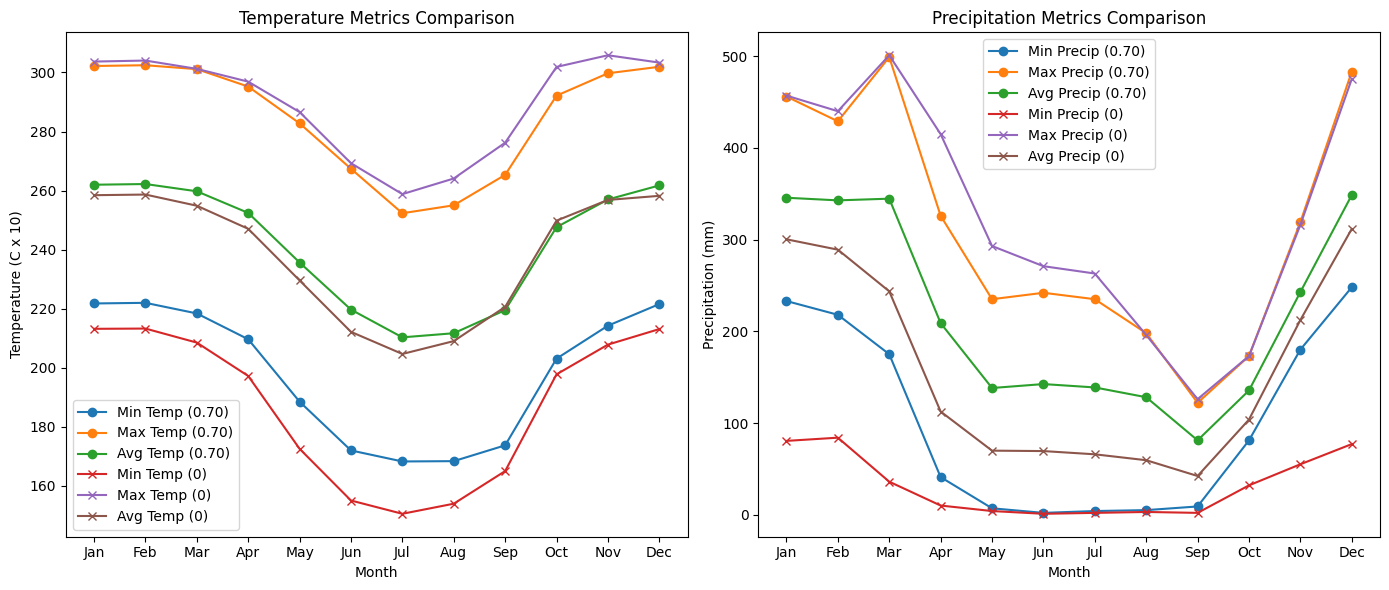

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df is your DataFrame and it includes a 'caffeine_percent' column.
# Filter the DataFrame for each caffeine group.
df_070 = coffee_data[coffee_data['caffeine_percent'] == 0.03]
df_0 = coffee_data[coffee_data['caffeine_percent'] == 0.00]

# Define the column names (ensure each list has exactly 12 columns).
temp_min_cols = [
    "clim_1_tmin1_jan", "clim_2_tmin2_feb", "clim_3_tmin3_mar",
    "clim_4_tmin4_apr", "clim_5_tmin5_may", "clim_6_tmin6_jun",
    "clim_7_tmin7_jul", "clim_8_tmin8_aug", "clim_9_tmin9_sep",
    "clim_10_tmin10_oct", "clim_11_tmin11_nov", "clim_12_tmin12_dec"
]

temp_max_cols = [
    "clim_13_tmax1_jan", "clim_14_tmax2_feb", "clim_15_tmax3_mar",
    "clim_16_tmax4_apr", "clim_17_tmax5_may", "clim_18_tmax6_jun",
    "clim_19_tmax7_jul", "clim_20_tmax8_aug", "clim_21_tmax9_sep",
    "clim_22_tmax10_oct", "clim_23_tmax11_nov", "clim_24_tmax12_dec"
]

precip_cols = [
    "clim_25_prec1_jan", "clim_26_prec2_feb", "clim_27_prec3_mar",
    "clim_28_prec4_apr", "clim_29_prec5_may", "clim_30_prec6_jun",
    "clim_31_prec7_jul", "clim_32_prec8_aug", "clim_33_prec9_sep",
    "clim_34_prec10_oct", "clim_35_prec11_nov", "clim_36_prec12_dec"
]

# Define month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate temperature metrics per month for caffeine_percent==0.70
tmin_avg_070 = [df_070[col].mean() for col in temp_min_cols]
tmax_avg_070 = [df_070[col].mean() for col in temp_max_cols]
temp_avg_070 = [(mn + mx) / 2 for mn, mx in zip(tmin_avg_070, tmax_avg_070)]

# Calculate precipitation metrics per month for caffeine_percent==0.70
precip_avg_070 = [df_070[col].mean() for col in precip_cols]
precip_min_070 = [df_070[col].min() for col in precip_cols]
precip_max_070 = [df_070[col].max() for col in precip_cols]

# Calculate temperature metrics per month for caffeine_percent==0
tmin_avg_0 = [df_0[col].mean() for col in temp_min_cols]
tmax_avg_0 = [df_0[col].mean() for col in temp_max_cols]
temp_avg_0 = [(mn + mx) / 2 for mn, mx in zip(tmin_avg_0, tmax_avg_0)]

# Calculate precipitation metrics per month for caffeine_percent==0
precip_avg_0 = [df_0[col].mean() for col in precip_cols]
precip_min_0 = [df_0[col].min() for col in precip_cols]
precip_max_0 = [df_0[col].max() for col in precip_cols]

# Plot the temperature metrics
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Plot metrics for caffeine_percent == 0.70
plt.plot(months, tmin_avg_070, marker='o', label='Min Temp (0.70)')
plt.plot(months, tmax_avg_070, marker='o', label='Max Temp (0.70)')
plt.plot(months, temp_avg_070, marker='o', label='Avg Temp (0.70)')
# Plot metrics for caffeine_percent == 0
plt.plot(months, tmin_avg_0, marker='x', label='Min Temp (0)')
plt.plot(months, tmax_avg_0, marker='x', label='Max Temp (0)')
plt.plot(months, temp_avg_0, marker='x', label='Avg Temp (0)')
plt.title('Temperature Metrics Comparison')
plt.xlabel('Month')
plt.ylabel('Temperature (C x 10)')
plt.legend()

# Plot the precipitation metrics
plt.subplot(1, 2, 2)
# Plot metrics for caffeine_percent == 0.70
plt.plot(months, precip_min_070, marker='o', label='Min Precip (0.70)')
plt.plot(months, precip_max_070, marker='o', label='Max Precip (0.70)')
plt.plot(months, precip_avg_070, marker='o', label='Avg Precip (0.70)')
# Plot metrics for caffeine_percent == 0
plt.plot(months, precip_min_0, marker='x', label='Min Precip (0)')
plt.plot(months, precip_max_0, marker='x', label='Max Precip (0)')
plt.plot(months, precip_avg_0, marker='x', label='Avg Precip (0)')
plt.title('Precipitation Metrics Comparison')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.legend()

plt.tight_layout()
plt.show()


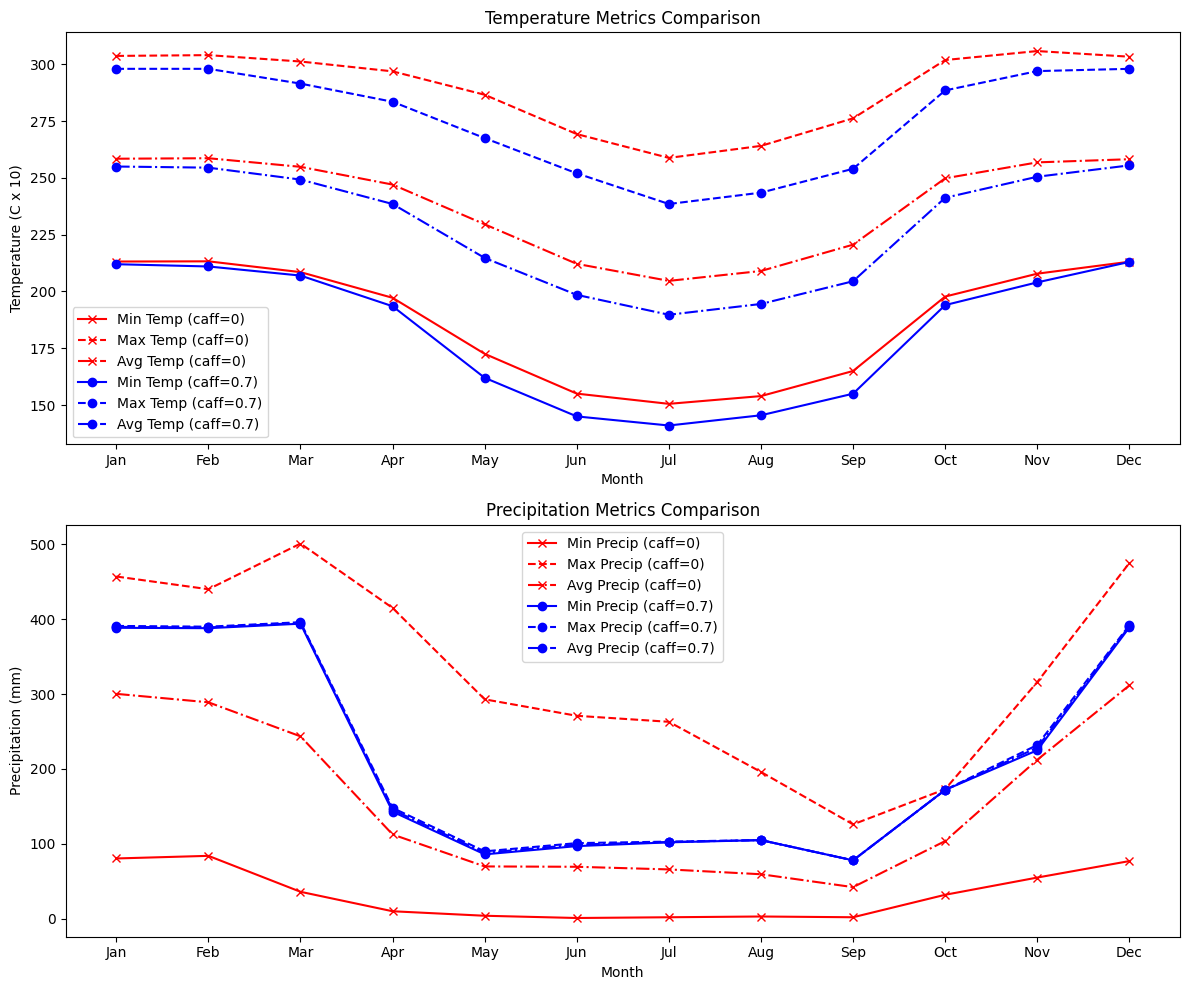

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with a 'caffeine_percent' column
df = coffee_data.copy()
# Define column lists (one per month)
temp_min_cols = [
    "clim_1_tmin1_jan", "clim_2_tmin2_feb", "clim_3_tmin3_mar",
    "clim_4_tmin4_apr", "clim_5_tmin5_may", "clim_6_tmin6_jun",
    "clim_7_tmin7_jul", "clim_8_tmin8_aug", "clim_9_tmin9_sep",
    "clim_10_tmin10_oct", "clim_11_tmin11_nov", "clim_12_tmin12_dec"
]

temp_max_cols = [
    "clim_13_tmax1_jan", "clim_14_tmax2_feb", "clim_15_tmax3_mar",
    "clim_16_tmax4_apr", "clim_17_tmax5_may", "clim_18_tmax6_jun",
    "clim_19_tmax7_jul", "clim_20_tmax8_aug", "clim_21_tmax9_sep",
    "clim_22_tmax10_oct", "clim_23_tmax11_nov", "clim_24_tmax12_dec"
]

precip_cols = [
    "clim_25_prec1_jan", "clim_26_prec2_feb", "clim_27_prec3_mar",
    "clim_28_prec4_apr", "clim_29_prec5_may", "clim_30_prec6_jun",
    "clim_31_prec7_jul", "clim_32_prec8_aug", "clim_33_prec9_sep",
    "clim_34_prec10_oct", "clim_35_prec11_nov", "clim_36_prec12_dec"
]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Function to calculate metrics per month for a given DataFrame subset
def calculate_metrics(df_subset):
    metrics = {}
    # Temperature metrics
    metrics['tmin_avg'] = [df_subset[col].mean() for col in temp_min_cols]
    metrics['tmax_avg'] = [df_subset[col].mean() for col in temp_max_cols]
    metrics['temp_avg'] = [(tmin + tmax) / 2 for tmin, tmax in zip(metrics['tmin_avg'], metrics['tmax_avg'])]
    
    # Precipitation metrics
    metrics['precip_min'] = [df_subset[col].min() for col in precip_cols]
    metrics['precip_max'] = [df_subset[col].max() for col in precip_cols]
    metrics['precip_avg'] = [df_subset[col].mean() for col in precip_cols]
    return metrics

# Create a dictionary for each caffeine group
groups = [0, 0.70]
group_metrics = {}
for group in groups:
    df_group = df[df['caffeine_percent'] == group]
    group_metrics[group] = calculate_metrics(df_group)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors = {0: 'red', 0.70: 'blue'}
markers = {0: 'x', 0.70: 'o'}

# Temperature metrics plot
for group in groups:
    m = group_metrics[group]
    axes[0].plot(months, m['tmin_avg'], marker=markers[group], linestyle='-', color=colors[group],
                 label=f'Min Temp (caff={group})')
    axes[0].plot(months, m['tmax_avg'], marker=markers[group], linestyle='--', color=colors[group],
                 label=f'Max Temp (caff={group})')
    axes[0].plot(months, m['temp_avg'], marker=markers[group], linestyle='-.', color=colors[group],
                 label=f'Avg Temp (caff={group})')

axes[0].set_title('Temperature Metrics Comparison')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Temperature (C x 10)')
axes[0].legend()

# Precipitation metrics plot
for group in groups:
    m = group_metrics[group]
    axes[1].plot(months, m['precip_min'], marker=markers[group], linestyle='-', color=colors[group],
                 label=f'Min Precip (caff={group})')
    axes[1].plot(months, m['precip_max'], marker=markers[group], linestyle='--', color=colors[group],
                 label=f'Max Precip (caff={group})')
    axes[1].plot(months, m['precip_avg'], marker=markers[group], linestyle='-.', color=colors[group],
                 label=f'Avg Precip (caff={group})')

axes[1].set_title('Precipitation Metrics Comparison')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()

plt.tight_layout()
plt.show()


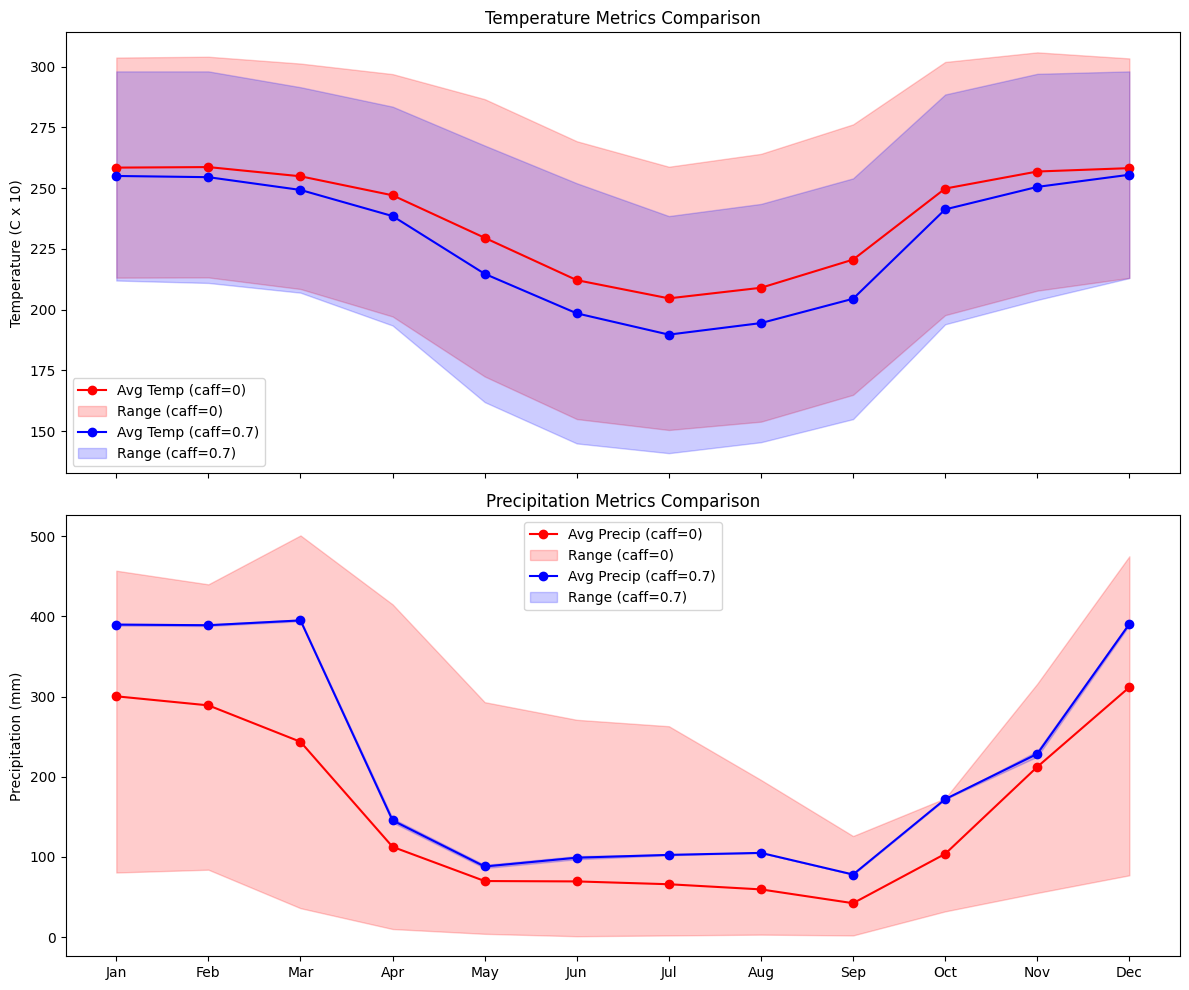

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with a 'caffeine_percent' column

# Define column lists for each metric
temp_min_cols = [
    "clim_1_tmin1_jan", "clim_2_tmin2_feb", "clim_3_tmin3_mar",
    "clim_4_tmin4_apr", "clim_5_tmin5_may", "clim_6_tmin6_jun",
    "clim_7_tmin7_jul", "clim_8_tmin8_aug", "clim_9_tmin9_sep",
    "clim_10_tmin10_oct", "clim_11_tmin11_nov", "clim_12_tmin12_dec"
]

temp_max_cols = [
    "clim_13_tmax1_jan", "clim_14_tmax2_feb", "clim_15_tmax3_mar",
    "clim_16_tmax4_apr", "clim_17_tmax5_may", "clim_18_tmax6_jun",
    "clim_19_tmax7_jul", "clim_20_tmax8_aug", "clim_21_tmax9_sep",
    "clim_22_tmax10_oct", "clim_23_tmax11_nov", "clim_24_tmax12_dec"
]

precip_cols = [
    "clim_25_prec1_jan", "clim_26_prec2_feb", "clim_27_prec3_mar",
    "clim_28_prec4_apr", "clim_29_prec5_may", "clim_30_prec6_jun",
    "clim_31_prec7_jul", "clim_32_prec8_aug", "clim_33_prec9_sep",
    "clim_34_prec10_oct", "clim_35_prec11_nov", "clim_36_prec12_dec"
]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def calculate_metrics(df_subset):
    metrics = {}
    # Temperature metrics
    metrics['tmin_avg'] = [df_subset[col].mean() for col in temp_min_cols]
    metrics['tmax_avg'] = [df_subset[col].mean() for col in temp_max_cols]
    metrics['temp_avg'] = [(tmin + tmax) / 2 for tmin, tmax in zip(metrics['tmin_avg'], metrics['tmax_avg'])]
    
    # Precipitation metrics
    metrics['precip_min'] = [df_subset[col].min() for col in precip_cols]
    metrics['precip_max'] = [df_subset[col].max() for col in precip_cols]
    metrics['precip_avg'] = [df_subset[col].mean() for col in precip_cols]
    return metrics

# Compute metrics for both groups
groups = {0: df[df['caffeine_percent'] == 0],
          0.70: df[df['caffeine_percent'] == 0.70]}

group_metrics = {g: calculate_metrics(sub_df) for g, sub_df in groups.items()}

# Set up the plot with two subplots: one for temperature, one for precipitation.
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
x = range(len(months))

# Choose distinct colors for each group
colors = {0: 'red', 0.70: 'blue'}

# Temperature plot: plot average temperature and fill between min and max.
for group, color in colors.items():
    m = group_metrics[group]
    axes[0].plot(x, m['temp_avg'], marker='o', label=f'Avg Temp (caff={group})', color=color)
    axes[0].fill_between(x, m['tmin_avg'], m['tmax_avg'], color=color, alpha=0.2,
                         label=f'Range (caff={group})')

axes[0].set_title('Temperature Metrics Comparison')
axes[0].set_ylabel('Temperature (C x 10)')
axes[0].legend()

# Precipitation plot: plot average precipitation and fill between min and max.
for group, color in colors.items():
    m = group_metrics[group]
    axes[1].plot(x, m['precip_avg'], marker='o', label=f'Avg Precip (caff={group})', color=color)
    axes[1].fill_between(x, m['precip_min'], m['precip_max'], color=color, alpha=0.2,
                         label=f'Range (caff={group})')

axes[1].set_title('Precipitation Metrics Comparison')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(months)
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
pd.set_option('display.max_rows', None)


In [21]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to compute VIF for each feature in a DataFrame
def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i)
                       for i in range(df.shape[1])]
    return vif_data

# Assume X is your DataFrame containing all your features
# For example, you might have already selected your numerical columns from coffee_data:
X = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent'])  # adjust as needed

# Compute VIF values for all features
vif_df = compute_vif(X)
print("Initial VIF values:")
print(vif_df)

# Set a VIF threshold. Features with a VIF above this threshold may be candidates for removal.
vif_threshold = 10

# Identify features with VIF above the threshold
high_vif_features = vif_df[vif_df["VIF"] > vif_threshold]["Feature"].tolist()
print("\nFeatures with VIF greater than", vif_threshold, ":", high_vif_features)

# Optionally, remove high VIF features
X_reduced = X.drop(columns=high_vif_features)
print("\nShape after removing high-VIF features:", X_reduced.shape)

# Recompute VIF after removal (if needed)
vif_df_reduced = compute_vif(X_reduced)
print("\nVIF values after removal:")
print(vif_df_reduced)


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Initial VIF values:
                      Feature           VIF
0            clim_1_tmin1_jan           inf
1            clim_2_tmin2_feb           inf
2            clim_3_tmin3_mar  2.064537e+04
3            clim_4_tmin4_apr  2.682822e+04
4            clim_5_tmin5_may  2.533275e+04
5            clim_6_tmin6_jun  2.139876e+04
6            clim_7_tmin7_jul  3.428034e+04
7            clim_8_tmin8_aug  3.736576e+04
8            clim_9_tmin9_sep  2.111973e+04
9          clim_10_tmin10_oct  1.146773e+04
10         clim_11_tmin11_nov  2.220619e+04
11         clim_12_tmin12_dec           inf
12          clim_13_tmax1_jan           inf
13          clim_14_tmax2_feb           inf
14          clim_15_tmax3_mar  1.181006e+04
15          clim_16_tmax4_apr  1.336775e+04
16          clim_17_tmax5_may  1.163916e+04
17          clim_18_tmax6_jun  1.282280e+04
18          clim_19_tmax7_jul  2.881707e+04
19          clim_20_tmax8_aug  3.278747e+04
20          clim_21_tmax9_sep  1.882774e+04
21         c

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [ ]:
import pandas as pd
import numpy as np

# Compute correlation matrix
corr_matrix = coffee_data.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Dropping these highly correlated features:", to_drop)

# Drop highly correlated features from the dataset
reduced_data = coffee_data.drop(columns=to_drop)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
X = coffee_data.drop(columns=['caffeine_class'])  # Assuming caffeine_class is the target variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)
